# Traffic Flow Optimization using Graph Algorithm

**Objective**
The objective of this project is to analyze and optimize traffic flow using real-world networks. The project models roads as graphs and applies shortest path algorithms to determine optimal routes under varying traffic conditions.

**Tools Used**
- Python
- OSMnx
- NetworkX
- Matplotlib
-----------------------------------------------------------------------------------------------------

## Data Collection

We use real-world road network data from OpenStreetMap using the OSMnx library. The area selected is Connaught Place, Delhi.

---------------------------------------------------------------------------------------------------

**IMPORTS**

In [133]:
# Import required libraries
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import random

# Configure OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = False

**LOAD GRAPH**

In [134]:
# Load road network around Connaught Place (2 km radius)
center_point = (28.6315, 77.2167)

G = ox.graph_from_point(center_point, dist=2000, network_type='drive')

# Display basic graph info
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 2030
Edges: 4775


## Graph Representation

The road network is represented as a graph:
- Nodes represent intersections
- Edges represent roads
- Edge weights represent distance and travel time
-----------------------------------------------------------------------------------------------------

**SELECT NODES**

In [135]:
# Convert nodes to list
nodes = list(G.nodes)

# Choose nodes far apart (top-left and bottom-right of map)
orig_node = nodes[100]
dest_node = nodes[-100]

print("Origin:", orig_node)
print("Destination:", dest_node)

Origin: 267251590
Destination: 11462925584


## Traffic Simulation

To simulate real-world conditions, traffic is introduced artificially.
Travel time is calculated based on road length and speed, and then adjusted using a traffic factor.

-----------------------------------------------------------------------------------------------------

**ADD TRAFFIC**

In [136]:
for u, v, k, data in G.edges(keys=True, data=True):
    base_time = data['length'] / 8.33
    
    # stronger traffic effect
    if random.random() < 0.5:
        traffic_factor = random.uniform(3, 8)
    else:
        traffic_factor = 1
    
    data['traffic_time'] = base_time * traffic_factor

## Shortest Path Computation

We use Dijkstra’s Algorithm to compute:
- Shortest distance path
- Fastest path considering traffic
----------------------------------------------------------------------------------------------------

**COST FUNCTION**

In [137]:
def compute_cost(route, weight, graph):
    total = 0
    
    for u, v in zip(route[:-1], route[1:]):
        edge_data = graph.get_edge_data(u, v)
        
        min_edge = min(edge_data.values(), key=lambda x: x.get(weight, float('inf')))
        total += min_edge.get(weight, 0)
    
    return total

**COMPUTE ROUTES**

In [138]:
# Shortest distance route
route_distance = nx.shortest_path(G, orig_node, dest_node, weight='length')
# Fastest route (traffic-aware)
route_traffic = nx.shortest_path(G, orig_node, dest_node, weight='traffic_time')

## Results

We compare the shortest route and the fastest route under traffic conditions.

--------------------------------------------------------------------------------------------------

**METRICS**

In [139]:
# Compute metrics
distance_m = compute_cost(route_distance, 'length', G)
time_shortest = compute_cost(route_distance, 'traffic_time', G)
time_fastest = compute_cost(route_traffic, 'traffic_time', G)

print("Shortest Distance (m):", distance_m)
print("Time on Shortest Route (min):", time_shortest / 60)
print("Fastest Route Time (min):", time_fastest / 60)

Shortest Distance (m): 3128.919818330609
Time on Shortest Route (min): 18.43040673252109
Fastest Route Time (min): 17.590613198476245


**Round value**

In [140]:
print(f"Fastest Time: {time_fastest/60:.2f} min")

Fastest Time: 17.59 min


**Showing improvement**

In [141]:
improvement = ((time_shortest - time_fastest) / time_shortest) * 100
print("Time saved (%):", improvement)

Time saved (%): 4.556565388017191


## Visualization

The routes are visualized on the map to compare their paths.

---------------------------------------------------------------------------------------------------

**PLOT**

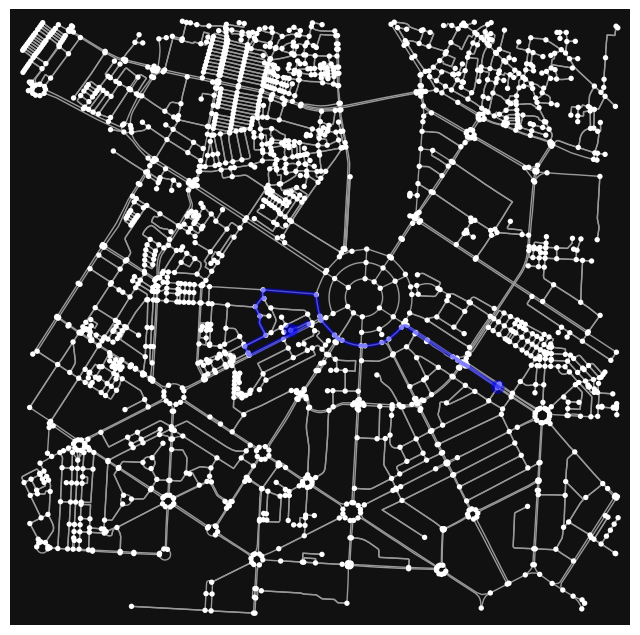

In [142]:
# Plot base graph
fig, ax = ox.plot_graph(G, show=False, close=False)

# Plot shortest route (distance-based)
ox.plot_graph_route(
    G,
    route_distance,
    ax=ax,
    route_linewidth=3,
    route_color='blue'
)

# Plot fastest route (traffic-aware)
ox.plot_graph_route(
    G,
    route_traffic,
    ax=ax,
    route_linewidth=3,
    route_color='red'
)

plt.show()

## Insight (especially for this graph plotted above)
In some cases, even after applying traffic conditions, the optimal route does not change. 
This indicates that the selected path is structurally efficient and remains optimal under moderate congestion.

-----------------------------------------------------------------------------------------------------

## Conclusion

- The shortest distance route is not always the fastest route.
- Traffic conditions significantly impact travel time.
- Alternative routes can reduce congestion delays.

This demonstrates the importance of dynamic traffic-aware routing systems in real-world transportation.

-----------------------------------------------------------------------------------------------------

## Key Insight

The difference between shortest and fastest routes highlights the importance of real-time traffic optimization in urban planning.

----------------------------------------------------------------------------------------------------

## Dynamic Routing Under Congestion

In real-world systems, routes are dynamically updated based on sudden congestion, road blockages, or changing traffic conditions.

In this section, we simulate such conditions to observe how the optimal route changes.

**DYNAMIC TRAFFIC + BLOCKAGE**

In [143]:
import copy

G_dynamic = copy.deepcopy(G)

# Step 1: initialize dynamic_time
for u, v, k, data in G_dynamic.edges(keys=True, data=True):
    base_time = data['length'] / 8.33
    data['dynamic_time'] = base_time

# Step 2: penalize area around shortest path
for node in route_distance:
    
    for neighbor in G_dynamic.neighbors(node):
        for k in G_dynamic[node][neighbor]:
            G_dynamic[node][neighbor][k]['dynamic_time'] *= 20   # huge penalty

# Step 3: compute new route
route_dynamic = nx.shortest_path(G_dynamic, orig_node, dest_node, weight='dynamic_time')

**METRICS**

In [144]:
# Calculate dynamic route time
dynamic_time = compute_cost(route_dynamic, 'dynamic_time', G_dynamic) / 60

print(f"Dynamic Route Time: {dynamic_time:.2f} minutes")

Dynamic Route Time: 29.98 minutes


**IMPROVEMENT VS DYNAMIC**

In [145]:
time_shortest_min = time_shortest / 60

improvement_dynamic = ((time_shortest_min - dynamic_time) / time_shortest_min) * 100

print(f"Time saved with dynamic routing: {improvement_dynamic:.2f}%")

Time saved with dynamic routing: -62.68%


**FINAL VISUALIZATION**

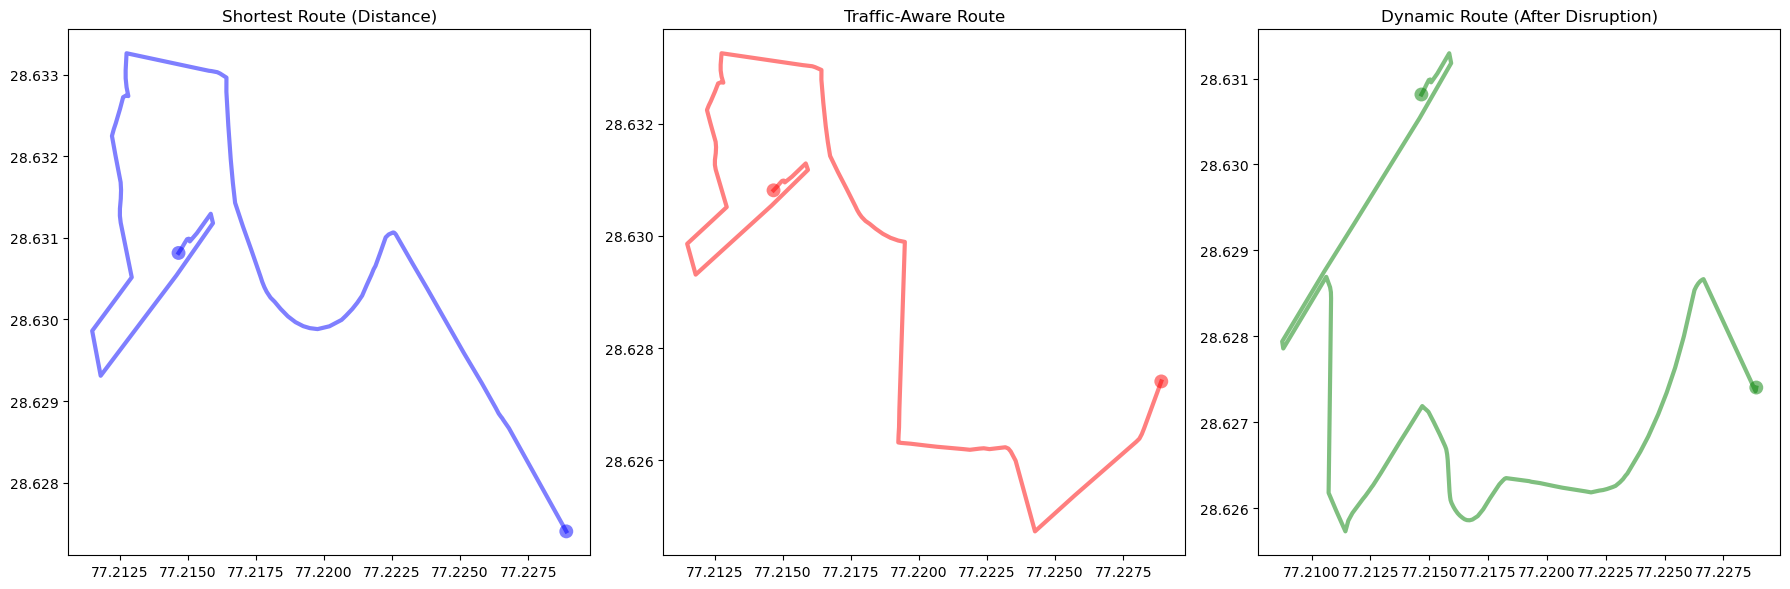

In [146]:
# --- SHOW ROUTES SEPARATELY (BEST VISUAL RESULT) ---

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Shortest Route
ox.plot_graph_route(
    G,
    route_distance,
    ax=axs[0],
    route_color='blue',
    route_linewidth=3,
    show=False,
    close=False
)
axs[0].set_title("Shortest Route (Distance)")

# Traffic Route
ox.plot_graph_route(
    G,
    route_traffic,
    ax=axs[1],
    route_color='red',
    route_linewidth=3,
    show=False,
    close=False
)
axs[1].set_title("Traffic-Aware Route")

# Dynamic Route
ox.plot_graph_route(
    G_dynamic,
    route_dynamic,
    ax=axs[2],
    route_color='green',
    route_linewidth=3,
    show=False,
    close=False
)
axs[2].set_title("Dynamic Route (After Disruption)")

plt.tight_layout()
plt.show()

Left → Shortest Path  
Middle → Traffic-Aware Path  
Right → Dynamic Rerouting after congestion

In [147]:
print("Shortest vs Traffic:", route_distance == route_traffic)
print("Shortest vs Dynamic:", route_distance == route_dynamic)

Shortest vs Traffic: False
Shortest vs Dynamic: False


In [148]:
print(f"Shortest Time: {time_shortest/60:.2f} min")
print(f"Traffic Time: {time_fastest/60:.2f} min")
print(f"Dynamic Time: {dynamic_time:.2f} min")

Shortest Time: 18.43 min
Traffic Time: 17.59 min
Dynamic Time: 29.98 min


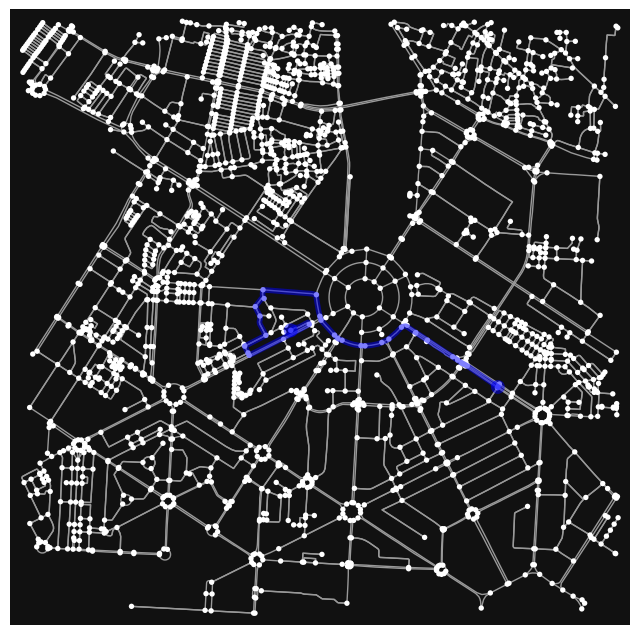

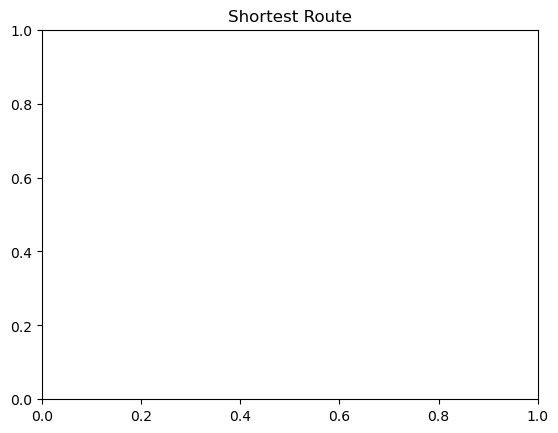

In [161]:
# --- SHOW ROUTES ONE BY ONE ---

mode = "shortest"   # change to: "traffic" or "dynamic"

if mode == "shortest":
    ox.plot_graph_route(
        G,
        route_distance,
        route_color='blue',
        route_linewidth=4
    )
    plt.title("Shortest Route")

elif mode == "traffic":
    ox.plot_graph_route(
        G,
        route_traffic,
        route_color='red',
        route_linewidth=4
    )
    plt.title("Traffic-Aware Route")

elif mode == "dynamic":
    ox.plot_graph_route(
        G_dynamic,
        route_dynamic,
        route_color='green',
        route_linewidth=4
    )
    plt.title("Dynamic Route (After Congestion)")

plt.show()